In [52]:
import os
import random
from collections import Counter

import numpy as np
import cv2
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D

In [71]:
raw_dir = "/Users/an/Desktop/Mini proyecto/behavior_model/dataset/raw"
frames_dir_4 = "/Users/an/Desktop/Mini proyecto/behavior_model/dataset/frames_4"
frames_dir_7 = "/Users/an/Desktop/Mini proyecto/behavior_model/dataset/frames_7"

IMG_SIZE = 224
FRAMES_PER_VIDEO = 4
SEED = 42
BATCH_SIZE = 16

In [61]:
classes_4 = ["sleeping", "toy", "sitting_still", "standing_still"]
classes_7 = ["lying", "rolling", "spinning", "sleeping", "toy", "sitting_still", "standing_still"]

In [117]:
PET_VOICE_LIBRARY = {
    "sleeping": {
        "zh": {
            "cute": {
                "start": ["别吵啦", "我先睡会儿", "今天先不营业", "让我再眯一下"],
                "end": ["我还在充电", "等我醒了再说", "困困模式已开启", "午睡是正经工作"]
            }
        },
        "es": {
            "cute": {
                "start": ["shhh", "déjame dormir un poquito", "ahora no atiendo", "cinco minutos más"],
                "end": ["estoy recargando energía", "luego hablamos", "modo siesta activado", "dormir también es trabajar"]
            }
        },
        "en": {
            "cute": {
                "start": ["shhh", "let me nap a bit", "not available right now", "five more minutes"],
                "end": ["I am recharging", "we can talk later", "nap mode activated", "sleeping is real work"]
            }
        }
    },

    "toy": {
        "zh": {
            "cute": {
                "start": ["这是我的宝贝", "我先抱着它", "谁也别抢", "今天战利品到手"],
                "end": ["我超喜欢这个", "这是我的快乐来源", "抱着就安心", "今天收获满满"]
            }
        },
        "es": {
            "cute": {
                "start": ["este es mi tesoro", "lo voy a abrazar un rato", "nadie me lo quite", "misión cumplida"],
                "end": ["me encanta esto", "esto me hace feliz", "así me siento seguro", "hoy he ganado"]
            }
        },
        "en": {
            "cute": {
                "start": ["this is my treasure", "I am keeping it close", "nobody take it away", "mission accomplished"],
                "end": ["I really love this", "this makes me happy", "I feel safe with it", "big win today"]
            }
        }
    },

    "sitting_still": {
        "zh": {
            "cute": {
                "start": ["我在这儿等你", "我先安静看着", "我现在很乖", "你继续说"],
                "end": ["我有在认真听", "我就这样陪着你", "看看你要干嘛", "先观察一下局势"]
            }
        },
        "es": {
            "cute": {
                "start": ["aquí te espero", "voy a mirarte en silencio", "hoy me porto bien", "sigue hablando"],
                "end": ["te estoy escuchando", "solo te acompaño", "a ver qué haces", "primero observo"]
            }
        },
        "en": {
            "cute": {
                "start": ["I am waiting here", "I will just watch quietly", "I am being good today", "go on"],
                "end": ["I am listening", "I am just keeping you company", "let me see what you do", "observing first"]
            }
        }
    },

    "standing_still": {
        "zh": {
            "cute": {
                "start": ["我已经准备好了", "我站好了", "随时可以出发", "我在待命"],
                "end": ["就等你一句话", "看看接下来做什么", "今天状态不错", "我很有精神"]
            }
        },
        "es": {
            "cute": {
                "start": ["ya estoy listo", "aquí estoy bien puesto", "podemos salir ya", "estoy en espera"],
                "end": ["solo falta que tú digas", "a ver qué hacemos ahora", "hoy tengo energía", "estoy muy activo"]
            }
        },
        "en": {
            "cute": {
                "start": ["I am ready", "I am standing by", "we can go anytime", "I am on standby"],
                "end": ["just say the word", "let us see what is next", "I feel great today", "I have a lot of energy"]
            }
        }
    },

    "lying": {
        "zh": {
            "cute": {
                "start": ["我先趴一下", "今天就想躺着", "先别催我", "我现在很放松"],
                "end": ["这才是舒服生活", "让我保持这个姿势", "今天主打一个松弛", "别影响我休息"]
            }
        },
        "es": {
            "cute": {
                "start": ["voy a quedarme tumbado", "hoy solo quiero descansar", "no me metas prisa", "estoy muy relajado"],
                "end": ["así se vive bien", "déjame en esta postura", "hoy toca tranquilidad", "no interrumpas mi descanso"]
            }
        },
        "en": {
            "cute": {
                "start": ["I am staying down here", "today I just want to rest", "do not rush me", "I feel very relaxed"],
                "end": ["this is the good life", "let me stay like this", "today is for relaxing", "do not interrupt my rest"]
            }
        }
    },

    "rolling": {
        "zh": {
            "cute": {
                "start": ["我滚一下怎么了", "今天心情很好", "看我翻个身", "这就是我的快乐"],
                "end": ["生活要有仪式感", "开心就要打滚", "请欣赏我的表演", "我现在超满足"]
            }
        },
        "es": {
            "cute": {
                "start": ["déjame rodar un poco", "hoy estoy de buen humor", "mira esta vuelta", "así expreso mi felicidad"],
                "end": ["la vida necesita estilo", "si soy feliz, ruedo", "disfruta del espectáculo", "ahora mismo estoy encantado"]
            }
        },
        "en": {
            "cute": {
                "start": ["let me roll for a bit", "I am in a great mood today", "look at this move", "this is my happiness"],
                "end": ["life needs style", "when I am happy, I roll", "enjoy the show", "I feel amazing right now"]
            }
        }
    },

    "spinning": {
        "zh": {
            "cute": {
                "start": ["我先转一圈", "今天有点兴奋", "别管我我正在开心", "这就是高能量模式"],
                "end": ["我停不下来", "这是我的小庆祝", "快乐到转圈", "我现在状态拉满"]
            }
        },
        "es": {
            "cute": {
                "start": ["voy a dar una vuelta", "hoy estoy emocionado", "déjame disfrutar esto", "modo energía alta activado"],
                "end": ["no puedo parar", "esta es mi pequeña celebración", "estoy tan feliz que giro", "ahora mismo estoy a tope"]
            }
        },
        "en": {
            "cute": {
                "start": ["I am going to spin around", "I am excited today", "let me enjoy this moment", "high energy mode activated"],
                "end": ["I cannot stop", "this is my little celebration", "I am so happy I spin", "I am fully energized right now"]
            }
        }
    },
        "Other / Mystery": {
        "zh": {
            "cute": {
                "start": ["这个动作有点神秘", "我也说不上来", "今天状态有点复杂", "这波我先保留意见"],
                "end": ["可能超出了我的理解范围", "让我再观察一下", "先当作谜之行为吧", "今天我有点难读懂"]
            }
        },
        "es": {
            "cute": {
                "start": ["esto está un poco misterioso", "no sabría decirlo", "hoy estoy difícil de interpretar", "me reservo mi opinión"],
                "end": ["quizá supera mis capacidades", "necesito observar un poco más", "vamos a llamarlo comportamiento misterioso", "hoy no soy fácil de leer"]
            }
        },
        "en": {
            "cute": {
                "start": ["this is a bit mysterious", "I cannot really tell", "today I am hard to read", "I will keep this to myself for now"],
                "end": ["this may be beyond my abilities", "I need a bit more observation", "let us call it mystery behavior", "I am not easy to interpret today"]
            }
        }
    }
}

def generate_pet_comment(behavior, lang="es", style="cute"):
    try:
        parts = PET_VOICE_LIBRARY[behavior][lang][style]
        connector = "，" if lang == "zh" else ", "
        return random.choice(parts["start"]) + connector + random.choice(parts["end"])
    except:
        if lang == "zh":
            return "我现在有点无语。"
        elif lang == "en":
            return "I have no comments right now."
        else:
            return "Ahora mismo no tengo comentarios."

In [65]:
print(generate_pet_comment("sleeping", lang="es", style="cute"))
print(generate_pet_comment("toy", lang="zh", style="cute"))
print(generate_pet_comment("rolling", lang="en", style="cute"))

déjame dormir un poquito, modo siesta activado
谁也别抢，这是我的快乐来源
look at this move, when I am happy, I roll


In [66]:
def count_files_by_class(base_dir, classes, file_type="vídeos"):
    print(f"Número de {file_type} por clase:")
    print()

    for cls in classes:
        class_path = os.path.join(base_dir, cls)

        if os.path.exists(class_path):
            files = [f for f in os.listdir(class_path) if not f.startswith(".")]
            print(f"{cls}: {len(files)} {file_type}")
        else:
            print(f"{cls}: carpeta no encontrada")


def extract_frames(raw_dir, frames_dir, classes, frames_per_video=4):
    os.makedirs(frames_dir, exist_ok=True)

    for cls in classes:
        input_dir = os.path.join(raw_dir, cls)
        output_dir = os.path.join(frames_dir, cls)
        os.makedirs(output_dir, exist_ok=True)

        if not os.path.exists(input_dir):
            print(f"Carpeta no encontrada: {input_dir}")
            continue

        videos = [f for f in os.listdir(input_dir) if not f.startswith(".")]

        for video_file in videos:
            video_path = os.path.join(input_dir, video_file)

            cap = cv2.VideoCapture(video_path)
            total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

            if total_frames <= 0:
                cap.release()
                print(f"No se pudo leer el vídeo: {video_file}")
                continue

            frame_ids = np.linspace(0, total_frames - 1, frames_per_video, dtype=int)
            video_name = os.path.splitext(video_file)[0]

            for i, frame_id in enumerate(frame_ids):
                cap.set(cv2.CAP_PROP_POS_FRAMES, frame_id)
                ret, frame = cap.read()

                if ret:
                    output_name = f"{video_name}_frame{i}.jpg"
                    output_path = os.path.join(output_dir, output_name)
                    cv2.imwrite(output_path, frame)

            cap.release()

    print("Extracción de frames completada.")

In [67]:
count_files_by_class(raw_dir, classes_4, file_type="vídeos")
print()
count_files_by_class(raw_dir, classes_7, file_type="vídeos")

Número de vídeos por clase:

sleeping: 13 vídeos
toy: 19 vídeos
sitting_still: 38 vídeos
standing_still: 14 vídeos

Número de vídeos por clase:

lying: 11 vídeos
rolling: 4 vídeos
spinning: 5 vídeos
sleeping: 13 vídeos
toy: 19 vídeos
sitting_still: 38 vídeos
standing_still: 14 vídeos


In [68]:
def create_generators(frames_dir, img_size=224, batch_size=16, seed=42, augment=False):
    if augment:
        train_datagen = ImageDataGenerator(
            rescale=1./255,
            validation_split=0.2,
            rotation_range=10,
            width_shift_range=0.1,
            height_shift_range=0.1,
            zoom_range=0.1,
            horizontal_flip=True
        )
    else:
        train_datagen = ImageDataGenerator(
            rescale=1./255,
            validation_split=0.2
        )

    val_datagen = ImageDataGenerator(
        rescale=1./255,
        validation_split=0.2
    )

    train_data = train_datagen.flow_from_directory(
        frames_dir,
        target_size=(img_size, img_size),
        batch_size=batch_size,
        class_mode="categorical",
        subset="training",
        seed=seed
    )

    val_data = val_datagen.flow_from_directory(
        frames_dir,
        target_size=(img_size, img_size),
        batch_size=batch_size,
        class_mode="categorical",
        subset="validation",
        seed=seed
    )

    class_names = list(train_data.class_indices.keys())

    print("Índices de clases:")
    print(train_data.class_indices)
    print("Orden de clases:", class_names)

    return train_data, val_data, class_names

In [72]:
extract_frames(raw_dir, frames_dir_4, classes_4, frames_per_video=FRAMES_PER_VIDEO)

Extracción de frames completada.


In [73]:
extract_frames(raw_dir, frames_dir_7, classes_7, frames_per_video=FRAMES_PER_VIDEO)

Extracción de frames completada.


In [74]:
train_data_4, val_data_4, class_names_4 = create_generators(
    frames_dir_4,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    augment=False
)

Found 265 images belonging to 4 classes.
Found 65 images belonging to 4 classes.
Índices de clases:
{'sitting_still': 0, 'sleeping': 1, 'standing_still': 2, 'toy': 3}
Orden de clases: ['sitting_still', 'sleeping', 'standing_still', 'toy']


In [75]:
train_data_7, val_data_7, class_names_7 = create_generators(
    frames_dir_7,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    augment=True
)

Found 326 images belonging to 7 classes.
Found 80 images belonging to 7 classes.
Índices de clases:
{'lying': 0, 'rolling': 1, 'sitting_still': 2, 'sleeping': 3, 'spinning': 4, 'standing_still': 5, 'toy': 6}
Orden de clases: ['lying', 'rolling', 'sitting_still', 'sleeping', 'spinning', 'standing_still', 'toy']


In [80]:
def build_cnn_model_4(img_size=224):
    model = Sequential([
        Conv2D(32, (3, 3), activation="relu", input_shape=(img_size, img_size, 3)),
        MaxPooling2D(2, 2),

        Conv2D(64, (3, 3), activation="relu"),
        MaxPooling2D(2, 2),

        Conv2D(128, (3, 3), activation="relu"),
        MaxPooling2D(2, 2),

        Flatten(),
        Dense(128, activation="relu"),
        Dropout(0.3),
        Dense(4, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [81]:
model_4 = build_cnn_model_4(img_size=IMG_SIZE)
model_4.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [82]:
def build_cnn_model_7(img_size=224):
    model = Sequential([
        Conv2D(32, (3, 3), activation="relu", input_shape=(img_size, img_size, 3)),
        MaxPooling2D(2, 2),
        Dropout(0.2),

        Conv2D(64, (3, 3), activation="relu"),
        MaxPooling2D(2, 2),
        Dropout(0.2),

        Conv2D(128, (3, 3), activation="relu"),
        MaxPooling2D(2, 2),
        Dropout(0.3),

        Flatten(),
        Dense(128, activation="relu"),
        Dropout(0.4),
        Dense(7, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [83]:
model_7 = build_cnn_model_7(img_size=IMG_SIZE)
model_7.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,863 (42.61 MB)

 Trainable params: 11,169,863 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [84]:
history_4 = model_4.fit(
    train_data_4,
    validation_data=val_data_4,
    epochs=5
)

Epoch 1/5
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 233ms/step - accuracy: 0.4189 - loss: 1.6179 - val_accuracy: 0.4615 - val_loss: 1.4125
Epoch 2/5
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 207ms/step - accuracy: 0.4642 - loss: 1.2426 - val_accuracy: 0.4615 - val_loss: 1.3029
Epoch 3/5
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 199ms/step - accuracy: 0.5623 - loss: 1.0338 - val_accuracy: 0.4000 - val_loss: 1.5157
Epoch 4/5
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 196ms/step - accuracy: 0.7170 - loss: 0.7161 - val_accuracy: 0.4154 - val_loss: 1.7096
Epoch 5/5
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 196ms/step - accuracy: 0.8453 - loss: 0.4593 - val_accuracy: 0.5077 - val_loss: 1.8245


In [85]:
history_7 = model_7.fit(
    train_data_7,
    validation_data=val_data_7,
    epochs=5
)

Epoch 1/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 228ms/step - accuracy: 0.3221 - loss: 3.5073 - val_accuracy: 0.3750 - val_loss: 1.7988
Epoch 2/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 220ms/step - accuracy: 0.3528 - loss: 1.7489 - val_accuracy: 0.3750 - val_loss: 1.8232
Epoch 3/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 231ms/step - accuracy: 0.3742 - loss: 1.7362 - val_accuracy: 0.3750 - val_loss: 1.8448
Epoch 4/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 226ms/step - accuracy: 0.3650 - loss: 1.7430 - val_accuracy: 0.3750 - val_loss: 1.7940
Epoch 5/5
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 216ms/step - accuracy: 0.3681 - loss: 1.7104 - val_accuracy: 0.3750 - val_loss: 1.8316


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


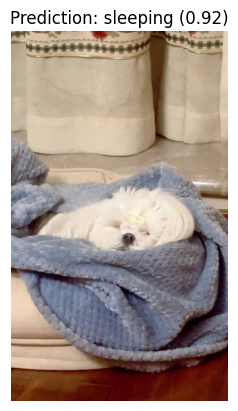

In [100]:
img_path = os.path.join(frames_dir_4, "sleeping", os.listdir(os.path.join(frames_dir_4, "sleeping"))[0])

img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized.astype("float32") / 255.0
img_array = np.expand_dims(img_array, axis=0)

preds = model_4.predict(img_array)[0]
pred_idx = np.argmax(preds)
confidence = preds[pred_idx]

if confidence < 0.55:
    pred_label = "Other / Mystery"
else:
    pred_label = class_names_4[pred_idx]

plt.imshow(img_rgb)
plt.title(f"Prediction: {pred_label} ({confidence:.2f})")
plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


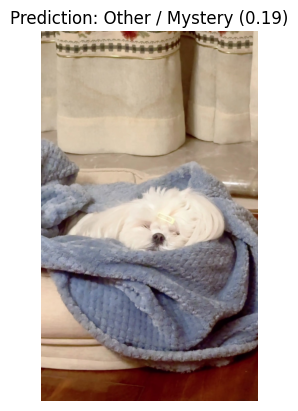

In [102]:
img_path = os.path.join(frames_dir_7, "sleeping", os.listdir(os.path.join(frames_dir_7, "sleeping"))[0])

img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
img_array = img_resized.astype("float32") / 255.0
img_array = np.expand_dims(img_array, axis=0)

preds = model_7.predict(img_array)[0]
pred_idx = np.argmax(preds)
confidence = preds[pred_idx]

if confidence < 0.55:
    pred_label = "Other / Mystery"
else:
    pred_label = class_names_7[pred_idx]

plt.imshow(img_rgb)
plt.title(f"Prediction: {pred_label} ({confidence:.2f})")
plt.axis("off")
plt.show()

In [111]:
def show_video_prediction(video_path, model, class_names, title="Final prediction", num_frames=3, threshold=0.55):
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print("No se pudo abrir el vídeo.")
        return

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_ids = np.linspace(0, total_frames - 1, num_frames, dtype=int)

    frames = []
    predictions = []
    confidences = []

    for fid in frame_ids:
        cap.set(cv2.CAP_PROP_POS_FRAMES, fid)
        ret, frame = cap.read()

        if ret:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame_resized = cv2.resize(frame_rgb, (IMG_SIZE, IMG_SIZE))
            frame_array = frame_resized.astype("float32") / 255.0
            frame_array = np.expand_dims(frame_array, axis=0)

            pred = model.predict(frame_array, verbose=0)[0]
            pred_idx = np.argmax(pred)
            pred_label = class_names[pred_idx]

            frames.append((fid, frame_rgb, pred_label))
            predictions.append(pred_label)
            confidences.append(np.max(pred))

    cap.release()

    most_common_label, count = Counter(predictions).most_common(1)[0]
    avg_confidence = np.mean(confidences)

    if count < 2 or avg_confidence < threshold:
        final_prediction = "Other / Mystery"
    else:
        final_prediction = most_common_label

    comment = generate_pet_comment(final_prediction, lang="es", style="cute")

    plt.figure(figsize=(15, 5))
    plt.suptitle(f"{title}: {final_prediction}\nComment: {comment}", fontsize=16)

    for i, (fid, frame_rgb, pred_label) in enumerate(frames):
        plt.subplot(1, len(frames), i + 1)
        plt.imshow(frame_rgb)
        plt.title(f"Frame {fid}\n{pred_label}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

    print("Predicciones por frame:", predictions)
    print("Confianzas:", [round(c, 3) for c in confidences])
    print("Predicción final:", final_prediction)
    print("Comentario:", comment)


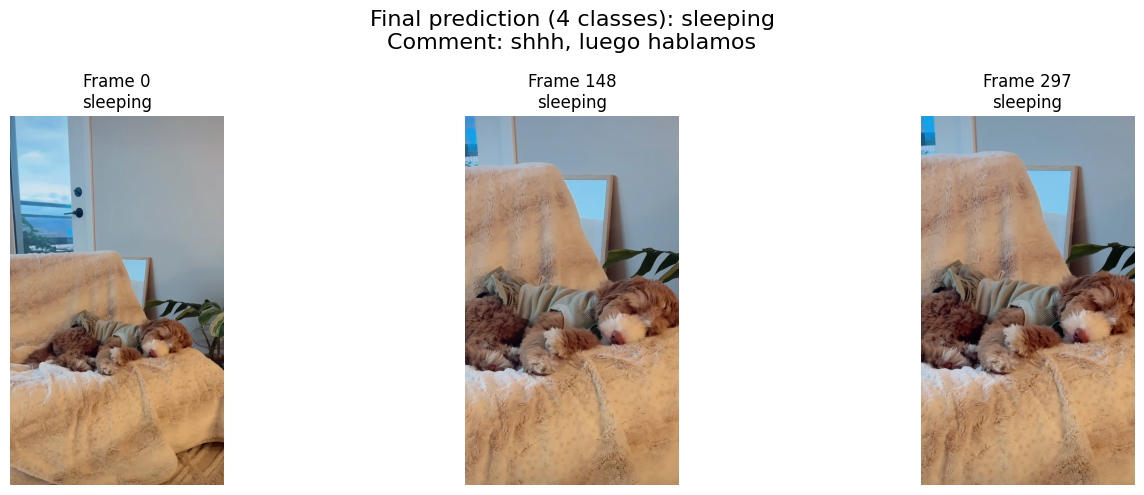

Predicciones por frame: ['sleeping', 'sleeping', 'sleeping']
Confianzas: [np.float32(0.93), np.float32(0.961), np.float32(0.972)]
Predicción final: sleeping
Comentario: shhh, luego hablamos


In [112]:
video_demo_4 = os.path.join(raw_dir, "sleeping", os.listdir(os.path.join(raw_dir, "sleeping"))[0])

show_video_prediction(
    video_demo_4,
    model_4,
    class_names_4,
    title="Final prediction (4 classes)",
    num_frames=3,
    threshold=0.55
)

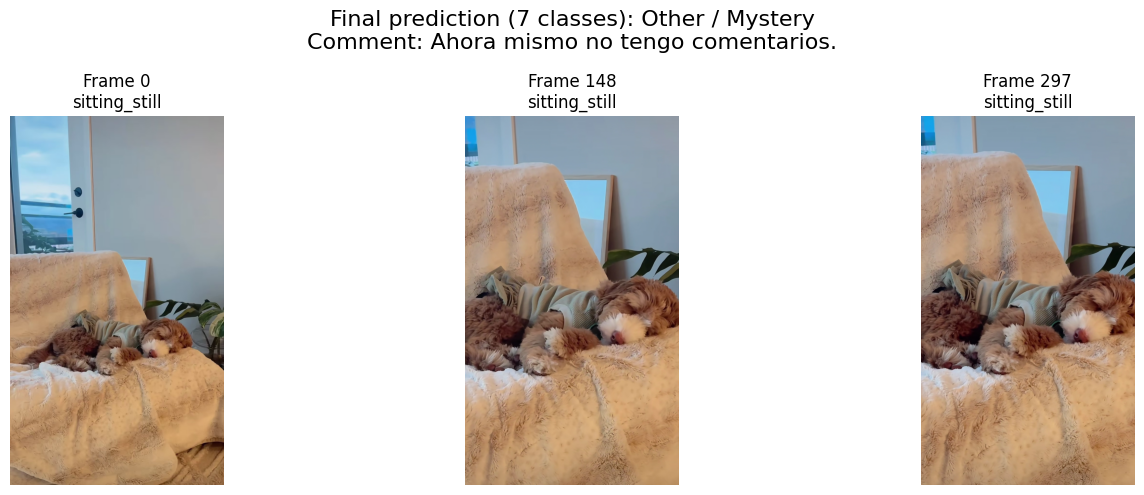

Predicciones por frame: ['sitting_still', 'sitting_still', 'sitting_still']
Confianzas: [np.float32(0.209), np.float32(0.2), np.float32(0.201)]
Predicción final: Other / Mystery
Comentario: Ahora mismo no tengo comentarios.


In [113]:
video_demo_7 = os.path.join(raw_dir, "sleeping", os.listdir(os.path.join(raw_dir, "sleeping"))[0])

show_video_prediction(
    video_demo_7,
    model_7,
    class_names_7,
    title="Final prediction (7 classes)",
    num_frames=3,
    threshold=0.55
)

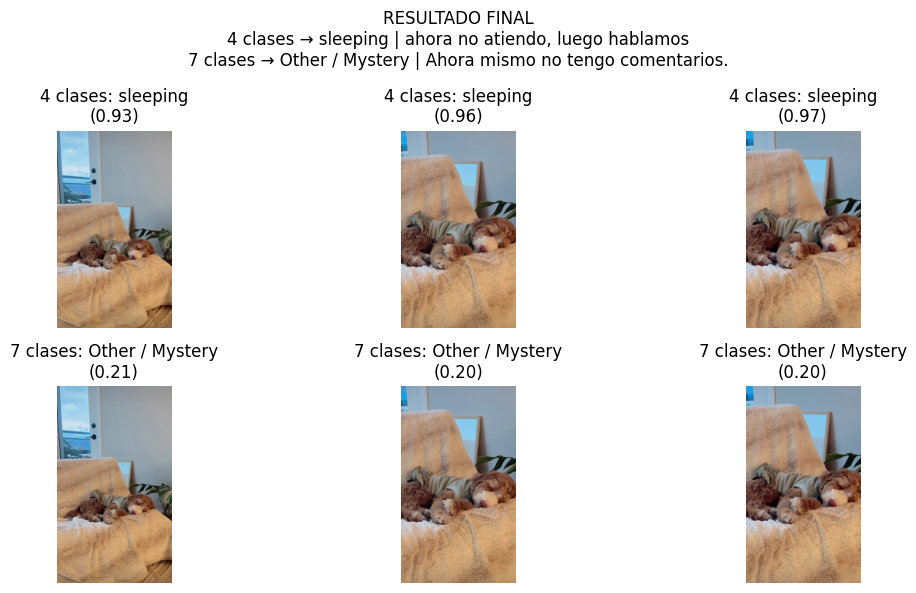

4 clases: ['sleeping', 'sleeping', 'sleeping'] → sleeping
Confianzas 4: [0.93, 0.96, 0.97]
Comentario 4: ahora no atiendo, luego hablamos
7 clases: ['Other / Mystery', 'Other / Mystery', 'Other / Mystery'] → Other / Mystery
Confianzas 7: [0.21, 0.2, 0.2]
Comentario 7: Ahora mismo no tengo comentarios.


In [115]:
video_demo = os.path.join(raw_dir, "sleeping", os.listdir(os.path.join(raw_dir, "sleeping"))[0])

frames = []
cap = cv2.VideoCapture(video_demo)

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
frame_ids = [0, total_frames // 2, total_frames - 1]

for fid in frame_ids:
    cap.set(cv2.CAP_PROP_POS_FRAMES, fid)
    ret, frame = cap.read()
    if ret:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame_resized = cv2.resize(frame_rgb, (IMG_SIZE, IMG_SIZE))
        frame_array = frame_resized.astype("float32") / 255.0
        frames.append((frame_rgb, np.expand_dims(frame_array, axis=0)))

cap.release()


preds_4 = []
preds_7 = []
conf_4 = []
conf_7 = []

for frame_rgb, frame_array in frames:
    p4 = model_4.predict(frame_array, verbose=0)[0]
    label_4 = class_names_4[np.argmax(p4)]
    score_4 = float(np.max(p4))

    if score_4 < 0.55:
        label_4 = "Other / Mystery"

    preds_4.append(label_4)
    conf_4.append(score_4)

    p7 = model_7.predict(frame_array, verbose=0)[0]
    label_7 = class_names_7[np.argmax(p7)]
    score_7 = float(np.max(p7))

    if score_7 < 0.55:
        label_7 = "Other / Mystery"

    preds_7.append(label_7)
    conf_7.append(score_7)


final_4, count_4 = Counter(preds_4).most_common(1)[0]
final_7, count_7 = Counter(preds_7).most_common(1)[0]

avg_conf_4 = np.mean(conf_4)
avg_conf_7 = np.mean(conf_7)

if count_4 < 2 or avg_conf_4 < 0.55:
    final_4 = "Other / Mystery"

if count_7 < 2 or avg_conf_7 < 0.55:
    final_7 = "Other / Mystery"


comment_4 = generate_pet_comment(final_4, lang="es", style="cute")
comment_7 = generate_pet_comment(final_7, lang="es", style="cute")

fig, axes = plt.subplots(2, len(frames), figsize=(12, 6))

for i, (frame_rgb, _) in enumerate(frames):
    axes[0, i].imshow(frame_rgb)
    axes[0, i].set_title(f"4 clases: {preds_4[i]}\n({conf_4[i]:.2f})")
    axes[0, i].axis("off")

    axes[1, i].imshow(frame_rgb)
    axes[1, i].set_title(f"7 clases: {preds_7[i]}\n({conf_7[i]:.2f})")
    axes[1, i].axis("off")

plt.suptitle(
    f"RESULTADO FINAL\n"
    f"4 clases → {final_4} | {comment_4}\n"
    f"7 clases → {final_7} | {comment_7}",
    fontsize=12
)

plt.tight_layout()
plt.show()

print("4 clases:", preds_4, "→", final_4)
print("Confianzas 4:", [round(x, 2) for x in conf_4])
print("Comentario 4:", comment_4)

print("7 clases:", preds_7, "→", final_7)
print("Confianzas 7:", [round(x, 2) for x in conf_7])
print("Comentario 7:", comment_7)

In [ ]:
import os

data_dir = "/Users/an/Desktop/Mini proyecto/behavior_model/dataset/raw"

classes = [c for c in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, c))]

print("Clases:", classes)

for cls in classes:
    path = os.path.join(data_dir, cls)
    files = os.listdir(path)
    print(f"{cls}: {len(files)} videos")

Clases: ['toy', 'rolling', 'spinning', 'sleeping', 'sitting_still', 'standing_still', 'lying']
toy: 19 videos
rolling: 4 videos
spinning: 5 videos
sleeping: 13 videos
sitting_still: 38 videos
standing_still: 14 videos
lying: 11 videos


In [98]:
import os

models_dir = "./models"
os.makedirs(models_dir, exist_ok=True)

print("Carpeta models creada.")

Carpeta models creada.


In [99]:
model_4.save(os.path.join(models_dir, "pet_behavior_model_4.h5"))
model_7.save(os.path.join(models_dir, "pet_behavior_model_7.h5"))

print("Modelos guardados correctamente.")

Modelos guardados correctamente.
